## Overview

This tutorial reproduces the ground truth benchmark from our
[paper](https://doi.org/10.1038/s41467-026-71607-5): a dataset of MDA-MB-231 cells
carrying **8 lentiviral clones**, profiled with the
[MAESTER](https://doi.org/10.1038/s41587-022-01210-8) protocol. Because the clonal
labels are known independently of the mitochondrial signal, they provide a
ground truth against which MT-SNV-based inference can be scored.

We will:

1. Pre-process the Allele Frequency Matrix (cell and variant filtering, genotyping)
2. Compute cell-cell distances in MT-SNV space and quantify how well they separate the ground truth clones
3. Infer a mitochondrial phylogeny and its clones
4. Score the inference against the lentiviral labels (ARI, NMI)

If you are new to MiTo, start from the
[Getting Started](getting_started.ipynb) tutorial instead: it walks through the same
workflow without the benchmarking detail.

**N.B.** a working MiTo installation is a prerequisite. See the
[installation guide](https://mito.readthedocs.io/en/latest/installation.html).


## Dataset
This tutorial starts by downloding our test dataset from zenodo. Here, we will download the `MDA_clones` benchmarking dataset introduced in our recent [pre-print](https://doi.org/10.1101/2025.06.17.660165). This is a tri-modal dataset including simoultaneous profiling of MT-SNVs, gene expression, and lentiviral barcodes (i.e., our ground truth clonal labels) for n=558 quality controlled cells.

In [1]:
# Set WD
WD='.'  # Change this to your working directory
!cd $WD

# Download and unzip test data
!wget https://zenodo.org/records/17225334/files/data_test.tar.gz && \
tar -xzvf data_test.tar.gz && \
rm data_test.tar.gz 

--2026-08-06 10:20:33--  https://zenodo.org/records/17225334/files/data_test.tar.gz


Resolving zenodo.org (zenodo.org)... 

188.185.43.153, 188.184.98.114, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.


HTTP request sent, awaiting response... 

200 OK
Length: 32419764 (31M) [application/octet-stream]
Saving to: 'data_test.tar.gz'

data_test.tar.gz      0%[                    ]       0  --.-KB/s               

...

data_test.tar.gz     98%[==================> ]  30.47M  1.15MB/s    eta 0s     

data_test.tar.gz     98%[==================> ]  30.60M  1.12MB/s    eta 0s     

data_test.tar.gz     99%[==================> ]  30.87M  1.14MB/s    eta 0s     

data_test.tar.gz    100%[===================>]  30.92M  1.13MB/s    in 23s     

2026-08-06 10:20:56 (1.37 MB/s) - 'data_test.tar.gz' saved [32419764/32419764]

x data_test/
x data_test/coverage.txt.gz


x data_test/cells_meta.csv
x data_test/afm_unfiltered.h5ad

The `MDA_clones` dataset we have just downloaded includes:

1. `afm_unfiltered.h5ad`: unfiltered AFM (the output from nf-MiTo PREPROCESS, with `--pp_method` = `maegatk`)
2. `cells_meta.csv`: cell metadata, including minimal QC covariates and ground truth clonal labels (`GBC` column)
3. `coverage.txt.gz`: cell-by-MT-genome-position coverage table

In [2]:
!ls data_test

afm_unfiltered.h5ad  cells_meta.csv  coverage.txt.gz


## Setup environment
We would also need to import all the necessary code, and to set up logging/visualization parameters:

In [3]:
import os
import logging
import numpy as np
import scanpy as sc
import mito as mt
import matplotlib.pyplot as plt
import plotting_utils as plu

# Logging
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

# Plotting parameters 
plu.set_rcParams({'figure.dpi':80})

# MiTo version and working directory
print(f"MiTo version: {mt.__version__}")
print(f"Working directory: {os.getcwd()}")

MiTo version: 0.2.1
Working directory: /private/tmp/mito_tutorial


## Load the Allelic Frequency Matrix (AFM)

We can now load our unfiltered AFM:


In [4]:
afm = sc.read('data_test/afm_unfiltered.h5ad')
print(afm)
print(f'scLT system: {afm.uns["scLT_system"]}')
print(f'Pre-processing pipeline adopted: {afm.uns["pp_method"]}')
print(f'Raw basecalls metrics: {afm.uns["raw_basecalls_metrics"]}')

AnnData object with n_obs × n_vars = 558 × 18846
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system'
    layers: 'AD', 'DP', 'qual', 'site_coverage', None (.X)
scLT system: MAESTER
Pre-processing pipeline adopted: maegatk
Raw basecalls metrics: {'total_basecalls': 6559093, 'variant_basecalls': 192201, 'variant_basecalls_for_annot_cells': 192201}


As we can see, our `afm` is an `AnnData` object equipped with the following slots:

* `.obs`: cell metadata, with minimal QC covariates and ground truth clonal labels (i.e., `GBC` column) from lentiviral barcoding
* `.var`: variant (MT-SNVs) metadata (minimal MT-SNVs annotation is present in this unfiltered AFM, but it will be updated in the next pre-processing steps)
* `.uns`: dataset parameters (e.g., `pp_method` and `scLT_system`) and metrics (e.g., `raw_basecalls_metrics`) 
* `.layers`: 4 parallel cell x variant site sparse matrices

At this stage, this `afm.layers` include:

* `AD`: alternative allele total UMI counts
* `DP`: total UMI counts (DP can be >0 only for entries with AD>0)
* `qual`: average base calling quality 
* `site_coverage`: total UMI counts (site_coverage can be >0 even for entries with AD=0)

Our `.X` slot instead store "raw" Allelic Frequencies (AFs, i.e., AD / site coverage).

In [5]:
# Selection of cells (n=2, rows) and variants (n=3, columns) with most non-zero AF values
cells = (afm.X>0).sum(axis=1).A1.argsort()[::-1][:2]
variants = (afm.X>0).sum(axis=0).A1.argsort()[::-1][:3]

# Print out each layer subsection
print('AF')
print(afm[cells, variants].X.toarray())
print('AD')
print(afm[cells, variants].layers['AD'].toarray())
print('DP')
print(afm[cells, variants].layers['DP'].toarray())
print('qual')
print(afm[cells, variants].layers['qual'].toarray())
print('site_coverage')
print(afm[cells, variants].layers['site_coverage'].toarray())


AF
[[1.        0.9994376 1.       ]
 [1.        1.        1.       ]]
AD
[[3043 1777 1859]
 [2962 1446 2492]]
DP
[[3043 1778 1859]
 [2962 1446 2492]]
qual
[[45 45 45]
 [45 45 45]]
site_coverage
[[3043. 1778. 1859.]
 [2962. 1446. 2492.]]


We can now proceed with AFM pre-processing.

## AFM pre-processing
Proper AFM pre-processing is crucial for robust lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165)), and MiTo provides highly-optimized methods to handle this important analysis step.

### Cell Filtering
As mentioned, cells in the unfiltered AFM have already passed standard Gene Expression QC. However, we still need make sure that only cells with an high-quality MT-SNVs profile are included in downstream analysis. Specifically, here we are looking for cells with sufficiently high and evenly distributed coverage across the entire MT-genome (or MAESTER target sites, ~13k sites across the ~16kB MT-genome). To perform cell filtering, MiTo implements the `mt.pp.filter_cells` function:

In [6]:
afm = mt.pp.filter_cells(afm, cell_filter='filter2')
afm_raw = afm.copy()  # Keep a copy of the AFM with all MT-SNVs, for visualization purposes

2026-08-06 10:21:02,683 - INFO - scLT system: MAESTER


2026-08-06 10:21:02,711 - INFO - Filtered cells (i.e., median target MT-genome coverage >=25 and fraction covered sites >=0.75: 375


As we can see, the number of cells dropped from 558 to 375 (i.e., 37% of the starting cells were filtered out because they did not satisfy the necessary quality standards).

### MT-SNVs filtering
We can now proceed with next step: MT-SNVs filtering. To do this, we will use the `mt.pp.filter_afm` function:

In [7]:
afm = mt.pp.filter_afm(afm, filtering='MiTo')

2026-08-06 10:21:02,764 - INFO - Compute general dataset metrics...


2026-08-06 10:21:02,765 - INFO - Compute vars_df as in Weng et al., 2024


2026-08-06 10:21:02,970 - INFO - Filter MT-SNVs...


2026-08-06 10:21:02,970 - INFO - scLT_system: MAESTER


2026-08-06 10:21:02,970 - INFO - pp_method: maegatk


...

2026-08-06 10:21:11,126 - INFO - Re-annotate variants in afm


2026-08-06 10:21:11,130 - INFO - Retain cells with at least 1 MT-SNVs: 287


2026-08-06 10:21:11,130 - INFO - Final afm after all filters: n cells=287, n features=23


2026-08-06 10:21:11,130 - INFO - Compute last (filtered) statistics.


2026-08-06 10:21:11,134 - INFO - AFM filtering complete: 8.37 s


As we can see from the printed logs, `mt.pp.filter_afm` performs different tasks to ensure only high-quality MT-SNVs (and the respective variant-bearing cells) are included for lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods).

In [8]:
print(afm)

AnnData object with n_obs × n_vars = 287 × 23
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt', 'n_confidently_detected', 'Moran I ', 'Moran I pvalue', 'mean_af', 'mean_cov', 'quality', 'n0', 'n1', 'n2', 'n5', 'n10', 'n50', 'Variant_CellN', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system', 'cell_filter', 'dataset_metrics', 'genotyping', 'distance_calculations', 'char_filter'
    obsp: 'distances'
    layers: 'AD', 'DP', 'qual', 'site_coverage', None (.X), 'bin'


Our final pre-processed AFM include 288 high-quality cells and 24 MT-SNVs.
As shown, `mt.pp.filter_afm` internally calls `mt.pp.call_genotypes` and `mt.pp.compute_distances`, which assign binary genotypes to each cell/MT-SNV combination (the new `bin` layer in `afm.layers`) and compute cell-cell distances in this binarized feature space (with the default `weighted_jaccard` distance metric, see the new `distances` slot in `afm.obsp`). `mt.pp.filter_afm` also annotates variants (`afm.var`) and update AFM parameters and metrics in `afm.uns`. 

### Dimensionality reduction
Cell-cell distances can be used together with feature matrices to reduce the dimensionality of the dataset and visualize relevent patterns in the data. MiTo's `mt.pp.reduce_dimensions` performs this operation:

In [9]:
mt.pp.reduce_dimensions(afm, method='UMAP')
print(afm)

2026-08-06 10:21:11,143 - INFO - Use bin layer


2026-08-06 10:21:11,143 - INFO - Use precomputed distances


2026-08-06 10:21:13,216 - INFO - UMAP spectral init does not support metric "weighted_jaccard": using "euclidean". Cell-cell distances are unaffected -- the kNN graph is precomputed.


AnnData object with n_obs × n_vars = 287 × 23
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt', 'n_confidently_detected', 'Moran I ', 'Moran I pvalue', 'mean_af', 'mean_cov', 'quality', 'n0', 'n1', 'n2', 'n5', 'n10', 'n50', 'Variant_CellN', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'raw_basecalls_metrics', 'scLT_system', 'cell_filter', 'dataset_metrics', 'genotyping', 'distance_calculations', 'char_filter'
    obsm: 'X_umap'
    obsp: 'distances'
    layers: 'AD', 'DP', 'qual', 'site_coverage', None (.X), 'bin'


In this case, the default `UMAP` method is used to embed cells in a 2-dimensional space stored as the new `X_umap` entry in the `.obsm` slot of our AFM. We will visualize these embeddings later.

Since this dataset comes with ground truth clonal labels, we can optionally check the quality of our MT-SNV space and its associated cell-cell distances. Here we use the area under the precision-recall curve (AUPRC) of within- versus between-clone distances: it summarises, in a single number, how well mutational distances separate the ground truth clonal populations (the categorical labels in the GBC column of `afm.obs`).


In [10]:
# Extract the distance matrix
D = afm.obsp['distances'].toarray()

# Quantify how well mutational distances separate the ground-truth GBC clones
auprc = mt.ut.distance_AUPRC(D, afm.obs['GBC'])
print(f"- Distance AUPRC: {auprc:.3f}")


- Distance AUPRC: 0.779


For details on these metrics choice and motivation, refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Lineage inference
After AFM pre-processing, lineage inference can start. First we will infer a mitochondrial cell phylogeny, and then, we will use this phylogeny to infer discrete mitochondrial clones. 

### Mitochondrial phylogenies
Phylogeny inference first, then. To accomplish this, we use the `mt.tl.build_tree` function, which implements several solvers from the [cassiopeia](https://github.com/YosefLab/Cassiopeia) package. Here, we use the the Unweighted Pair Group Method with Arithmetic Mean (UPGMA) method. Note that, on top of cassiopeia solvers, nf-MiTo support other tree-building algorithms (i.e., `mpboot` and `iqtree`, see [nf-MiTo](https://github.com/andrecossa5/nf-MiTo) for reference).

In [11]:
tree = mt.tl.build_tree(afm, precomputed=True, solver='UPMGA')

2026-08-06 10:21:13,725 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-08-06 10:21:13,726 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}


2026-08-06 10:21:13,727 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


### Mitochondrial clones

We can now use this mitochondrial phylogeny to infer discrete clonal labels. For this, we will use the `mt.tl.MiToTreeAnnotator` class and its `clonal_inference` method.

In [12]:
model = mt.tl.MiToTreeAnnotator(tree)
model.clonal_inference()

2026-08-06 10:21:14,387 - INFO - Retrieve cell assignment to tree clades


2026-08-06 10:21:14,397 - INFO - Compute mutations enrichment: n muts=23


2026-08-06 10:21:14,656 - INFO - Start Grid Search. n hyper-parameter combinations to explore: 36


Grid Search:   0%|          | 0/36 [00:00<?, ?it/s]

Grid Search:   3%|▎         | 1/36 [00:00<00:10,  3.44it/s]

...

2026-08-06 10:21:26,698 - INFO - Compute expansion pvalues


2026-08-06 10:21:26,700 - INFO - Estimate cell fitness scores


node_ranking: inferring ancestral fitness... 

done in  1.3 s
node_ranking: calculating alternative rankings... done in  0.1 s


2026-08-06 10:21:29,462 - INFO - MiTo clonal inference finished. 15.07 s


### (Optional) lineage inference evaluation

Evaluate the quality of our lineage inference using metrics that evaluate the correlation between tree topology and underlying character distances, the evolutionary pattern of MT-SNVs on tree branches, and the relationship between ground truth clones (GBC) and MiTo clones:

In [13]:
# Tree structure metrics
corr_distances, _ = mt.ut.calculate_corr_distances(tree)
ci_scores = mt.ut.CI(tree)
ri_scores = mt.ut.RI(tree)

print(f"Tree-structure metrics:")
print(f"- Distances correlation: {corr_distances:.3f}")
print(f"- Median CI: {np.median(ci_scores):.3f}")
print(f"- Median RI: {np.median(ri_scores):.3f}")

# Clonal assignment metrics
test_mask = tree.cell_meta['MiTo clone'].isna()
assigned_cells = ~test_mask
gbc_assigned = tree.cell_meta.loc[assigned_cells, 'GBC']
mito_assigned = tree.cell_meta.loc[assigned_cells, 'MiTo clone']
ari = mt.ut.custom_ARI(gbc_assigned, mito_assigned)
nmi = mt.ut.normalized_mutual_info_score(gbc_assigned, mito_assigned)

print(f"Clonal assignment metrics:")
print(f"- Adjusted Rand Index: {ari:.3f}")
print(f"- Normalized Mutual Information: {nmi:.3f}")

Tree-structure metrics:
- Distances correlation: 0.597
- Median CI: 0.333
- Median RI: 0.996
Clonal assignment metrics:
- Adjusted Rand Index: 0.950
- Normalized Mutual Information: 0.928


For more details on these metrics, please refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Visualization
We have pre-processed our AFM and leverage MT-SNVs to infer mitochondrial cell lineages. We can now create comprehensive visualizations to assess our results.

### MT-SNVs selection
First, we would like to visualize the properties of our filtered MT-SNVs callset.


We start by plotting the Allelic Frequency spectrum of MT-SNVs before and after AFM pre-processing:

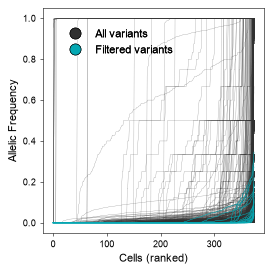

In [14]:
# Annotate vars in afm_raw
mt.pp.annotate_vars(afm_raw)

# Set colors
colors = {'All variants': '#303030', 'Filtered variants': '#05A8B3'}

# Plot allele frequency spectrum (before vs after filtering)
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.vars_AF_spectrum(afm_raw, ax=ax, color=colors['All variants'], alpha=.7, linewidth=.2)
mt.pl.vars_AF_spectrum(afm_raw[:,afm.var_names], ax=ax, color=colors['Filtered variants'], linewidth=.5, alpha=1)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We would also like to visualize the number of positive cells (+cells) vs the average number of UMIs supporting alternative allele basecalls across +cells, for each MT-SNV:

2026-08-06 10:21:34,453 - INFO - Re-annotate variants in afm


2026-08-06 10:21:34,645 - INFO - Re-annotate variants in afm


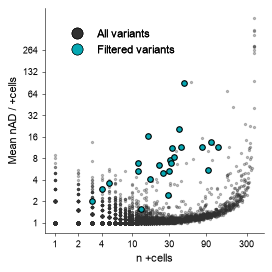

In [15]:
# Set xticks
xticks = [1, 2, 4, 10, 30, 90, 300, 1100]

# Plot number of cells vs mean alternative allele depth
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.plot_ncells_nAD(afm_raw, ax=ax, xticks=xticks, color='#303030', s=2, alpha=.3, label='All variants')
mt.pl.plot_ncells_nAD(afm, ax=ax, color='#05A8B3', xticks=xticks, s=5, alpha=1, markeredgecolor='k', label='Filtered variants')
plu.format_ax(ax=ax, ylabel='Mean nAD / +cells', xlabel='n +cells', reduced_spines=True)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We might also want to know where are these MT-SNVs distributed across the MT-genome

23


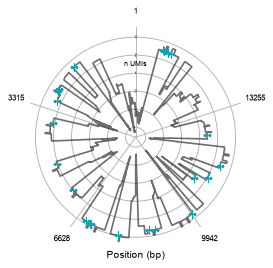

In [16]:
# Load coverage data
cov = mt.io.read_coverage(afm_raw, 'data_test/coverage.txt.gz', 'MDA_clones')

# Visualize MT genome coverage in polar coordinates, with MT-SNVs highlighted
fig, ax = plt.subplots(figsize=(3.5,3.5), subplot_kw={'projection': 'polar'})
mt.pl.MT_coverage_polar(
    cov, 
    var_subset=afm.var_names, ax=ax,
    yticks_size=4,
    kwargs_subset={'markersize': 8, 'c': '#05A8B3', 'label': 'Selected variants'}, 
    kwargs_main={'c': '#303030', 'linewidth': 1.5, 'alpha': .7, 'label': 'All positions'}
)
fig.tight_layout()
plt.show()

... which MT-gene harbour them

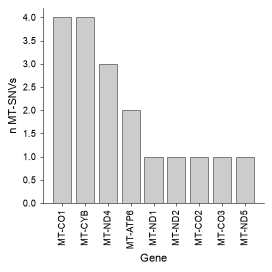

In [17]:
# Load MT-genes annotation
ref_df = mt.ut.load_mt_gene_annot()
df_plot = ref_df.query('mut in @afm.var_names')

# Plot variant distribution across MT genes
fig, ax = plt.subplots(figsize=(3.5,3.5))
plu.counts_plot(df_plot, 'Symbol', width=.8, ax=ax, color='#C0C0C0', edgecolor='k', with_label=False)
plu.format_ax(ax=ax, rotx=90, ylabel='n MT-SNVs', xlabel='Gene', reduced_spines=True)
fig.tight_layout()
plt.show()

... and which mutational signatures are they enriched for:

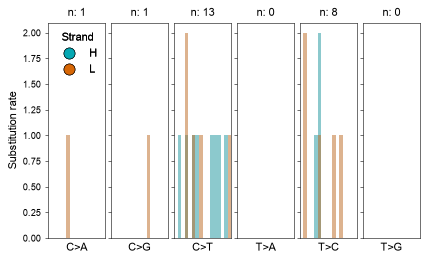

In [18]:
fig = mt.pl.mut_profile(afm.var_names, figsize=(6,3.5))
fig.tight_layout()
plt.show()

We would also like to visualize our characters and cell-cell distances in clustered heatmaps:

2026-08-06 10:21:37,798 - INFO - Compute tree from precomputed cell-cell distances...


2026-08-06 10:21:37,798 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-08-06 10:21:37,798 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}


2026-08-06 10:21:37,799 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


2026-08-06 10:21:37,949 - INFO - Retrieve cell assignment to tree clades


2026-08-06 10:21:37,958 - INFO - Compute mutations enrichment: n muts=23


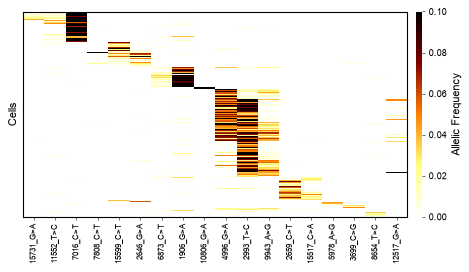

In [19]:
fig, ax = plt.subplots(figsize=(6,3.5))
mt.pl.heatmap_variants(afm, ax=ax, cmap='afmhot_r')
fig.tight_layout()
plt.show()

2026-08-06 10:21:44,288 - INFO - Compute tree from precomputed cell-cell distances...


2026-08-06 10:21:44,289 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-08-06 10:21:44,289 - INFO - Precomputed bin layer: bin_method=MiTo and binarization_kwargs={'t_prob': 0.7, 't_vanilla': 0.0, 'min_AD': 2, 'min_cell_prevalence': 0.1}


2026-08-06 10:21:44,290 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


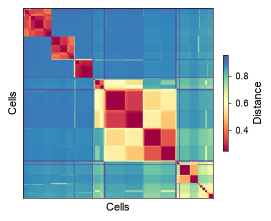

In [20]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
mt.pl.heatmap_distances(afm, ax=ax, cmap='Spectral')
fig.tight_layout()
plt.show()

### Lineage inference 
Before dealing with phylogeny inference diagnostics, we would also like to visualize if our ground-truth labels cluster in UMAP space.

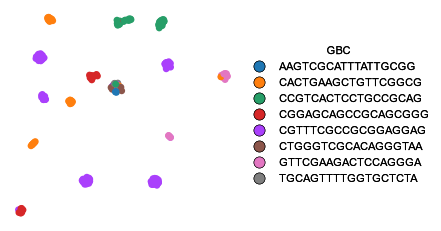

In [21]:
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = plu.create_palette(afm.obs, 'GBC', sc.pl.palettes.vega_10_scanpy)
mt.pl.draw_embedding(afm, feature='GBC', ax=ax, categorical_cmap=colors, legend=True, size=150)
plt.subplots_adjust(right=.7)
plt.show()

As we can see, to a great extent, lentiviral clones nicely cluster together.


Finally we would like to visualize our main downstream analysis product, our cell phylogeny and MiTo clones:

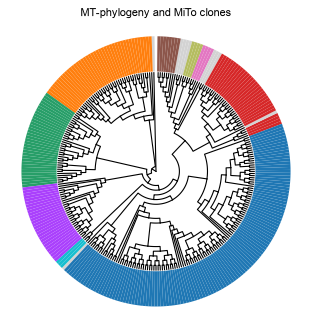

In [22]:
fig, ax = plt.subplots(figsize=(4, 4.2))
mt.pl.plot_tree(tree, ax=ax, features=['MiTo clone'], colorstrip_width=7.5)
ax.set_title('MT-phylogeny and MiTo clones')
fig.tight_layout()
plt.show()

## Outlook

More detailed tutorials, starting from the nf-MiTo INFER output (bootstrapped cell
phylogenies), will be available soon.
